In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)

(7043, 21)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [8]:
df = df.dropna(subset=['TotalCharges'])

In [9]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

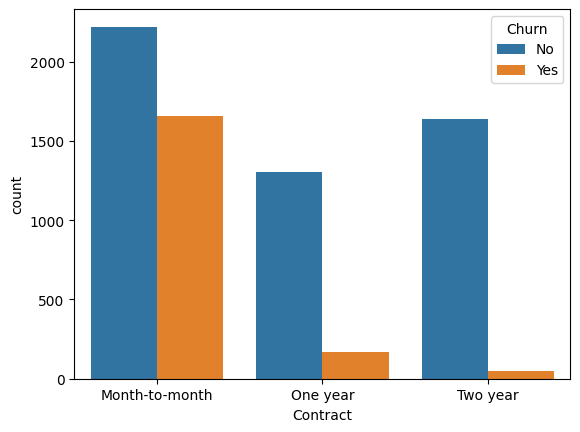

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df,x='Contract',hue='Churn')
plt.show()

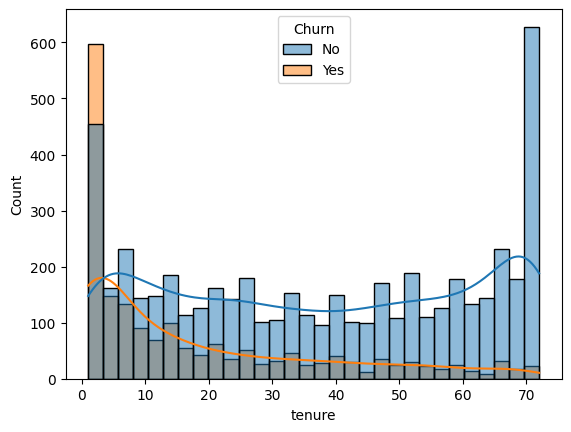

In [11]:
sns.histplot(data=df,x='tenure',hue='Churn',bins=30,kde=True)
plt.show()

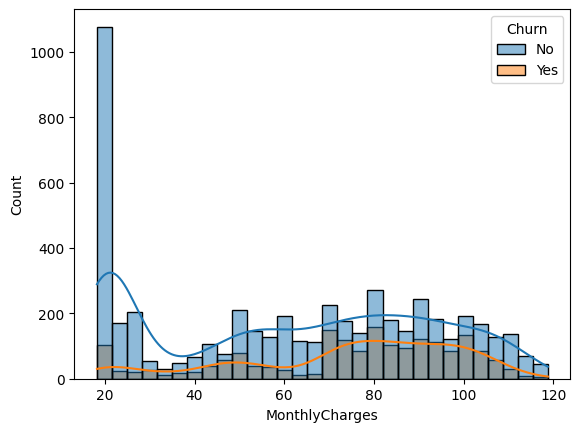

In [12]:
sns.histplot(data=df,x='MonthlyCharges',hue='Churn',bins=30,kde=True)
plt.show()

In [13]:
#Customers on month to month contracts churn far more than the those on 1 or 2 year contracts.

In [14]:
df = df.drop('customerID',axis=1)

In [15]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [16]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='object').columns.tolist()

print('Categorical:',cat_cols)
print("Numerical:",num_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\asus\AppData\Local\Temp\ipykernel_10256\2054001983.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()
C:\Users\asus\AppData\Local\Temp\ipykernel_10256\2054001983.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_

In [17]:
df_encoded = pd.get_dummies(df,columns=cat_cols,drop_first=True)

In [18]:
X = df_encoded.drop('Churn',axis=1)
y = df_encoded['Churn']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                 'StreamingTV', 'StreamingMovies']


In [23]:
df['NumServices'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val not in ['No', 'No internet service', 'No phone service']),
    axis=1
)

In [24]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


C:\Users\asus\AppData\Local\Temp\ipykernel_10256\4228324163.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [25]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [28]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumServices,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,0,1.321816,0.981556,1.659900,1.224919,True,True,True,True,False,...,False,False,False,False,False,True,False,True,False,False
7003,0,-0.267410,-0.971546,-0.562252,-0.505953,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3355,0,1.444064,0.837066,1.756104,0.792201,False,True,False,True,False,...,False,False,False,False,False,True,False,True,False,False
4494,0,-1.204646,0.641092,-0.908326,-0.073235,True,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
3541,0,0.669826,-0.808787,-0.101561,-0.505953,False,True,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [29]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

Churn
0    4130
1    4130
Name: count, dtype: int64


In [31]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

Churn
0    4130
1    4130
Name: count, dtype: int64


In [33]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score,roc_curve,precision_recall_curve)
import matplotlib.pyplot as plt


In [35]:
log_reg = LogisticRegression(max_iter=1000,random_state=42)
log_reg.fit(X_train_res,y_train_res)

y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:,1]

In [36]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train_res,y_train_res)

y_pred_rf = rf.predict(X_test)
y_proba_rf =  rf.predict_proba(X_test)[:,1]

In [37]:
xgb = XGBClassifier(eval_metrics='logloss',random_state=42)
xgb.fit(X_train_res,y_train_res)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

C:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:12:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"===== {name} =====")
    print(classification_report(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print()

In [39]:
evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407

ROC-AUC: 0.827604816457957

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.55      0.63      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407

ROC-AUC: 0.813508497652339

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.56      0.63      0.59       374

    accuracy                           0.77     

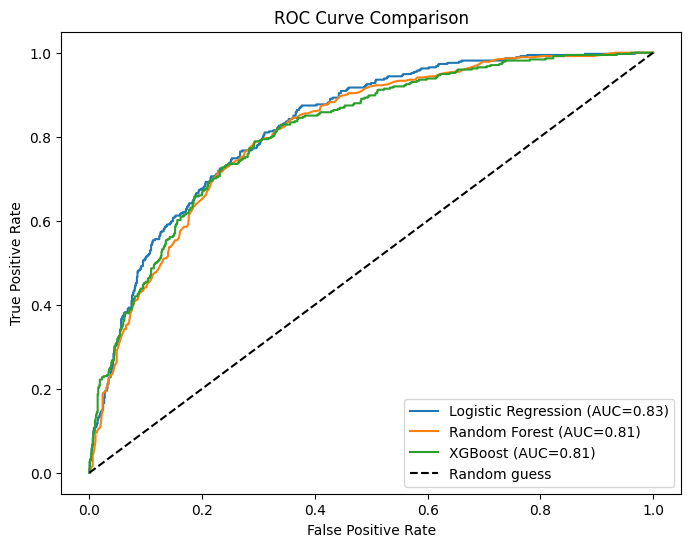

In [40]:
plt.figure(figsize=(8,6))

for name, y_proba in [("Logistic Regression", y_proba_log), 
                        ("Random Forest", y_proba_rf), 
                        ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [41]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Precision": [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb)],
    "F1-Score": [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.530815,0.713904,0.608894,0.827605
1,Random Forest,0.553738,0.633690,0.591022,0.813508
2,XGBoost,0.556604,0.631016,0.591479,0.813603


In [42]:
import sys
!{sys.executable} -m pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.68.4-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.66.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.48.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.68.4-py3-none-any.whl (676 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ----------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

C:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


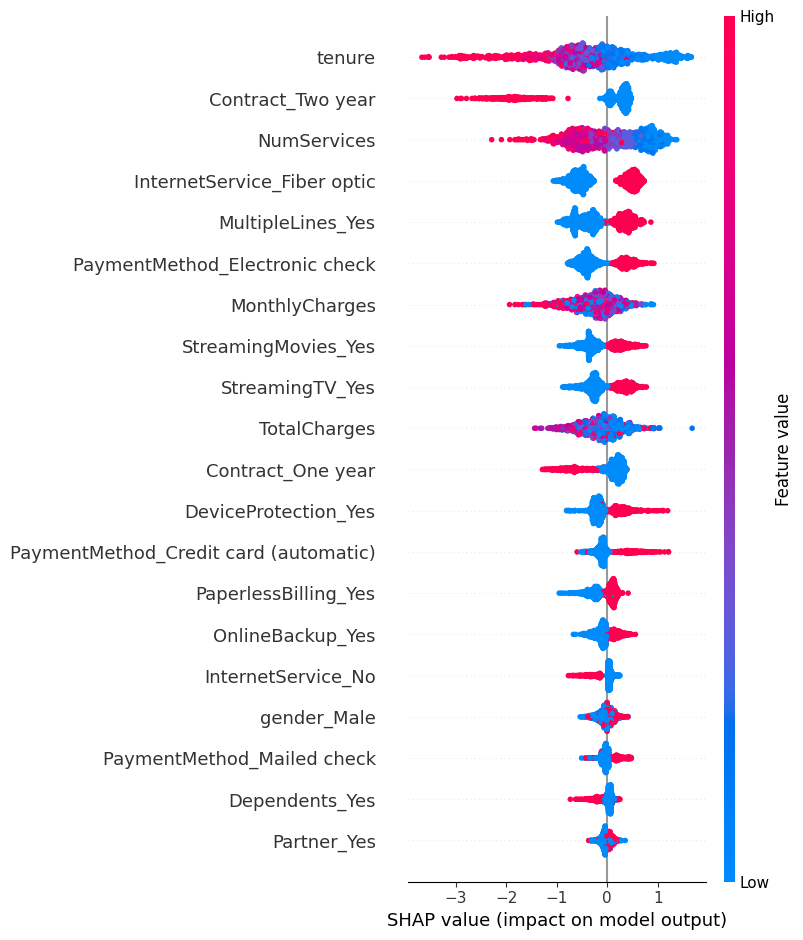

In [44]:
shap.summary_plot(shap_values,X_test)

In [46]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.close()

In [47]:
import joblib

joblib.dump(xgb, 'models/churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

joblib.dump(X_train.columns.tolist(),'models/model_columns.pkl')

['models/model_columns.pkl']

In [48]:
import sys
!{sys.executable} -m pip install streamlit

   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.3 MB 434.4 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/10.3 MB 633.7 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/10.3 MB 633.7 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/10.3 MB 633.7 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/10.3 MB 633.7 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/10.3 MB 504.8 kB/s eta 0:00:19
   ----- ---------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
